In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/preprocessed/imputed_data.csv')

feature_cols = [col for col in df.columns if col not in
                ["result_match", "stage", "season", "date", "home_team", "away_team"]]

X_= df[["match_api_id", "stage", "season", "date", "home_team", "away_team"]].copy()

y = df[['result_match']]
X = df[feature_cols].copy()


def freedman_diaconis_bins(series):
    """
    Calculate the optimal number of bins using the Freedman-Diaconis rule.
    """
    data = series.dropna()

    q25, q75 = np.percentile(data, [10, 85])
    iqr = q75 - q25

    bin_width = 2 * iqr / np.cbrt(len(data))

    if bin_width == 0:
        return 10

    data_range = data.max() - data.min()
    n_bins = int(np.ceil(data_range / bin_width))
    return n_bins

In [19]:
# drop = ['home_last_team_possession',
#                                   'rolling_avg_goals_home',
#                                   'rolling_avg_shoton_home',
#                                   'away_last_team_possession',
#                                   'team_acceleration_home',
#                                   'goal_conversion_rate_home',
#                                   'rolling_stability_goals_conversion_rate_home',
#                                   'rolling_avg_goals_away',
#                                   'rolling_stability_goal_away',
#                                   'rolling_avg_goals_conversion_rate_away',
#                                   'rolling_stability_goals_conversion_rate_away',
#                                   'rolling_avg_shoton_away',
#                                   'rolling_stability_shoton_away',
#                                   'rolling_avg_goals_conversion_rate_diff',
#                                   'rolling_stability_goals_conversion_rate_diff',
#                                   'rolling_stability_shoton_diff',
#                                   'points_diff',
#                                   'points_ratio',
#                                   ]
# X.drop(drop, axis=1, inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2975 entries, 0 to 2974
Data columns (total 49 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   match_api_id                                  2975 non-null   int64  
 1   result_match                                  2975 non-null   int64  
 2   stage                                         2975 non-null   int64  
 3   season                                        2975 non-null   object 
 4   date                                          2975 non-null   object 
 5   home_team                                     2975 non-null   int64  
 6   away_team                                     2975 non-null   int64  
 7   points_home                                   2975 non-null   float64
 8   points_away                                   2975 non-null   float64
 9   home_team_last_goal                           2975 non-null   f

In [21]:
n_bins_points_diff = freedman_diaconis_bins(X['points_diff'])
n_bins_rolling_avg_goals_diff = freedman_diaconis_bins(X['rolling_avg_goals_diff'])
n_bins_rolling_avg_goals_conversion_rate_diff = freedman_diaconis_bins(X['rolling_avg_goals_conversion_rate_diff'])
n_bins_rolling_avg_shoton_away = freedman_diaconis_bins(X['rolling_avg_shoton_away'])
n_bins_rolling_stability_shoton_home = freedman_diaconis_bins(X['rolling_stability_shoton_home'])
n_bins_rolling_stability_goal_diff = freedman_diaconis_bins(X['rolling_stability_goal_diff'])
n_bins_rolling_avg_goals_conversion_rate_home = freedman_diaconis_bins(X['rolling_avg_goals_conversion_rate_home'])
n_bins_rolling_stability_goals_conversion_rate_home = freedman_diaconis_bins(X['rolling_stability_goals_conversion_rate_home'])
n_bins_avg_team_acceleration_home = freedman_diaconis_bins(X['avg_team_acceleration_home'])
n_bins_rolling_avg_shoton_home = freedman_diaconis_bins(X['rolling_avg_shoton_home'])
n_bins_goal_conversion_rate_away = freedman_diaconis_bins(X['goal_conversion_rate_away'])
n_bins_rolling_avg_goals_home = freedman_diaconis_bins(X['rolling_avg_goals_home'])
n_bins_acceleration_difference = freedman_diaconis_bins(X['acceleration_difference'])
n_bins_avg_team_aggression_home = freedman_diaconis_bins(X['avg_team_aggression_home'])
n_bins_avg_team_aggression_away = freedman_diaconis_bins(X['avg_team_aggression_away'])
n_bins_away_team_last_shoton = freedman_diaconis_bins(X['away_team_last_shoton'])
n_bins_home_team_last_possession = freedman_diaconis_bins(X['home_team_last_possession'])
n_bins_away_team_last_possession = freedman_diaconis_bins(X['away_team_last_possession'])

print(f"Optimal bins for points_diff: {n_bins_points_diff}")
print(f"Optimal bins for rolling_avg_goals_diff: {n_bins_rolling_avg_goals_diff}")
print(f"Optimal bins for rolling_avg_goals_conversion_rate_diff: {n_bins_rolling_avg_goals_conversion_rate_diff}")
print(f"Optimal bins for rolling_avg_shoton_away: {n_bins_rolling_avg_shoton_away}")
print(f"Optimal bins for rolling_stability_shoton_home: {n_bins_rolling_stability_shoton_home}")
print(f"Optimal bins for rolling_stability_goal_diff: {n_bins_rolling_stability_goal_diff}")
print(f"Optimal bins for rolling_avg_goals_conversion_rate_home: {n_bins_rolling_avg_goals_conversion_rate_home}")
print(f"Optimal bins for rolling_stability_goals_conversion_rate_home: {n_bins_rolling_stability_goals_conversion_rate_home}")
print(f"Optimal bins for avg_team_acceleration_home: {n_bins_avg_team_acceleration_home}")
print(f"Optimal bins for rolling_avg_shoton_home: {n_bins_rolling_avg_shoton_home}")
print(f"Optimal bins for goal_conversion_rate_away: {n_bins_goal_conversion_rate_away}")
print(f"Optimal bins for rolling_avg_goals_home: {n_bins_rolling_avg_goals_home}")
print(f"Optimal bins for acceleration_difference: {n_bins_acceleration_difference}")
print(f"Optimal bins for avg_team_aggression_home: {n_bins_avg_team_aggression_home}")
print(f"Optimal bins for avg_team_aggression_away: {n_bins_avg_team_aggression_away}")
print(f"Optimal bins for away_team_last_shoton: {n_bins_away_team_last_shoton}")
print(f"Optimal bins for home_team_last_possession: {n_bins_home_team_last_possession}")
print(f"Optimal bins for away_team_last_possession: {n_bins_away_team_last_possession}")

X['n_bins_points_diff'] = pd.cut(X['points_diff'], bins=n_bins_home_team_last_possession).cat.codes
X['n_bins_rolling_avg_goals_diff'] = pd.cut(X['rolling_avg_goals_diff'], bins=n_bins_rolling_avg_goals_diff).cat.codes
X['n_bins_rolling_avg_goals_home'] = pd.cut(X['rolling_avg_goals_home'], bins=n_bins_rolling_avg_goals_conversion_rate_diff).cat.codes
X['n_bins_rolling_avg_goals_away'] = pd.cut(X['rolling_avg_goals_away'], bins=n_bins_rolling_avg_shoton_away).cat.codes
X['n_bins_rolling_avg_goals_conversion_rate_away'] = pd.cut(X['rolling_avg_goals_conversion_rate_away'], bins=n_bins_rolling_stability_shoton_home).cat.codes
X['n_bins_rolling_avg_goals_conversion_rate_diff'] = pd.cut(X['rolling_avg_goals_conversion_rate_diff'], bins=n_bins_rolling_stability_goal_diff).cat.codes
X['n_bins_rolling_avg_shoton_home'] = pd.cut(X['rolling_avg_shoton_home'], bins=n_bins_rolling_avg_goals_conversion_rate_home).cat.codes
X['n_bins_rolling_avg_shoton_away'] = pd.cut(X['rolling_avg_shoton_away'], bins=n_bins_rolling_stability_goals_conversion_rate_home).cat.codes
X['n_bins_avg_team_acceleration_home'] = pd.cut(X['avg_team_acceleration_home'], bins=n_bins_avg_team_acceleration_home).cat.codes
X['n_bins_goal_conversion_rate_home'] = pd.cut(X['goal_conversion_rate_home'], bins=n_bins_rolling_avg_shoton_home).cat.codes
X['n_bins_rolling_stability_goal_away'] = pd.cut(X['rolling_stability_goal_away'], bins=n_bins_goal_conversion_rate_away).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_home'] = pd.cut(X['rolling_stability_goals_conversion_rate_home'], bins=n_bins_rolling_avg_goals_home).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_away'] = pd.cut(X['rolling_stability_goals_conversion_rate_away'], bins=n_bins_acceleration_difference).cat.codes
X['n_bins_rolling_stability_goals_conversion_rate_diff'] = pd.cut(X['rolling_stability_goals_conversion_rate_diff'], bins=n_bins_avg_team_aggression_home).cat.codes
X['n_bins_rolling_stability_shoton_away'] = pd.cut(X['rolling_stability_shoton_away'], bins=n_bins_avg_team_aggression_away).cat.codes
X['n_bins_rolling_stability_shoton_diff'] = pd.cut(X['rolling_stability_shoton_diff'], bins=n_bins_away_team_last_shoton).cat.codes
X['n_bins_home_team_last_possession'] = pd.cut(X['home_team_last_possession'], bins=n_bins_home_team_last_possession).cat.codes
X['n_bins_away_team_last_possession'] = pd.cut(X['away_team_last_possession'], bins=n_bins_away_team_last_possession).cat.codes

Optimal bins for points_diff: 27
Optimal bins for rolling_avg_goals_diff: 32
Optimal bins for rolling_avg_goals_conversion_rate_diff: 61
Optimal bins for rolling_avg_shoton_away: 26
Optimal bins for rolling_stability_shoton_home: 31
Optimal bins for rolling_stability_goal_diff: 35
Optimal bins for rolling_avg_goals_conversion_rate_home: 46
Optimal bins for rolling_stability_goals_conversion_rate_home: 57
Optimal bins for avg_team_acceleration_home: 22
Optimal bins for rolling_avg_shoton_home: 24
Optimal bins for goal_conversion_rate_away: 110
Optimal bins for rolling_avg_goals_home: 28
Optimal bins for acceleration_difference: 24
Optimal bins for avg_team_aggression_home: 18
Optimal bins for avg_team_aggression_away: 18
Optimal bins for away_team_last_shoton: 26
Optimal bins for home_team_last_possession: 22
Optimal bins for away_team_last_possession: 28


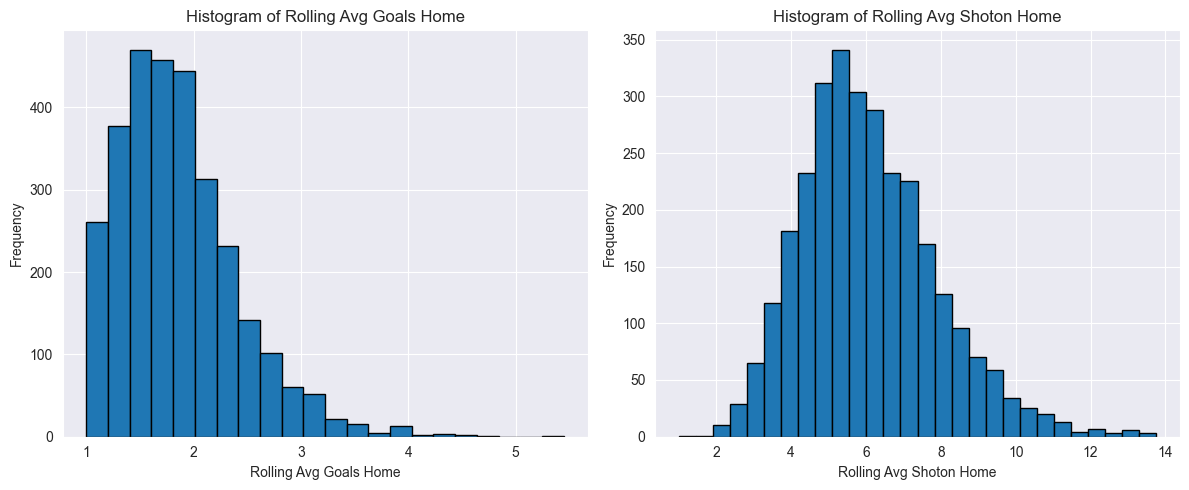

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rolling_avg_goals_home'].dropna(), bins=n_bins_home_team_last_possession, edgecolor='black')
plt.title('Histogram of Rolling Avg Goals Home')
plt.xlabel('Rolling Avg Goals Home')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['rolling_avg_shoton_home'].dropna(), bins=n_bins_away_team_last_possession, edgecolor='black')
plt.title('Histogram of Rolling Avg Shoton Home')
plt.xlabel('Rolling Avg Shoton Home')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [23]:
X['result_match']=y
X = pd.merge(X, X_, on='match_api_id')
X.to_csv('../../data/preprocessed/X_binned.csv', index=False)
X

,match_api_id,points_home,points_away,home_team_last_goal,home_team_last_shoton,home_team_last_possession,away_team_last_goal,away_team_last_shoton,away_team_last_possession,avg_team_strength_home,...,n_bins_rolling_stability_shoton_away,n_bins_rolling_stability_shoton_diff,n_bins_home_team_last_possession,n_bins_away_team_last_possession,result_match,stage,season,date,home_team,away_team
0,489063,3.0,4.0,1.00,12.0,34.0,1.000000,1.0,55.0,78.318182,...,2,12,5,18,1,3,2008/2009,2008-08-30,9825,10261
1,489068,3.0,3.0,1.00,7.0,47.0,3.000000,1.0,47.0,63.924242,...,2,12,10,15,1,3,2008/2009,2008-08-30,8549,10194
2,489069,3.0,0.0,3.00,5.0,53.0,1.000000,2.0,66.0,71.318182,...,3,12,12,22,0,3,2008/2009,2008-08-30,8559,8659
3,489070,4.0,0.0,1.00,5.0,47.0,1.000000,7.0,52.0,63.318182,...,3,12,10,17,0,3,2008/2009,2008-08-30,8667,8528
4,489066,3.0,6.0,2.00,5.0,48.0,2.000000,11.0,46.0,77.030303,...,3,12,10,15,0,3,2008/2009,2008-08-31,10252,8650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,1987599,44.0,34.0,1.00,4.0,44.0,4.000000,6.0,69.0,72.327273,...,4,14,8,23,1,38,2015/2016,2016-05-15,8668,9850
2971,1987598,49.0,80.0,2.00,5.0,53.0,3.000000,4.0,67.0,65.445455,...,3,12,12,23,0,38,2015/2016,2016-05-15,8455,8197
2972,1987597,68.0,17.0,2.00,7.0,31.0,1.666667,1.0,65.0,70.627273,...,6,13,4,22,1,38,2015/2016,2016-05-15,9825,10252
2973,1987601,34.0,70.0,1.75,6.0,50.0,1.000000,6.0,47.0,79.690909,...,3,14,11,15,1,38,2015/2016,2016-05-15,10261,8586


In [ ]:
from src.eda.PartialDependencyAnalyzer import PartialDependenceAnalyzer

analyzer_pdp = PartialDependenceAnalyzer(
    features=[
        'rolling_stability_goals_conversion_rate_home', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='average'

)

analyzer_pdp.fit_and_visualize(X, y, )

In [ ]:
analyzer_ice = PartialDependenceAnalyzer(
    features=[
        'home_last_team_possession', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='individual'
)

analyzer_ice.fit_and_visualize(X, y, )